<div style="display: flex; align-items: center; justify-content: flex-start; text-align: left;">
    <img src="https://upload.wikimedia.org/wikipedia/commons/thumb/6/68/Logo_universidad_icesi.svg/960px-Logo_universidad_icesi.svg.png" width="300" style="margin-right: 20px;">
    <div>
        <h3 style="margin: 0;">FACULTAD BARBERI DE INGENIERÍA, DISEÑO Y CIENCIAS APLICADAS</h3>
        <h3 style="margin: 0;">ALGORITMOS Y PROGRAMACIÓN III</h3>
    </div>
</div>

# Proyecto Final

Integrantes:
- ANGY MARIA HURTADO OSORIO A00401755
- HIDEKI TAMURA HERNANDEZ A00348618
- DAVID VERGARA LAVERDE A00402237


## Modelado - Experimentos de Machine Learning Tradicional

Este notebook contiene los experimentos utilizando modelos clásicos (Random Forest, SVM, XGBoost) para predecir **simultáneamente** la calidad y el tamaño de las frutas/verduras usando un enfoque `MultiOutputClassifier`.

Siguiendo las mejores prácticas, las funciones de evaluación pesadas se han abstraído en `src/evaluation/evaluate.py`.

In [8]:
import sys
import os
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.multioutput import MultiOutputClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import joblib
from tqdm import tqdm


# Añadir la carpeta raíz al path para poder importar desde la carpeta src
sys.path.append(os.path.abspath('..'))

from src.evaluation.evaluate import evaluate_multioutput_model
from src.utils.helpers import extract_features_for_ml

### 1. Carga de Datos y Preprocesamiento

Para el Machine Learning tradicional, asumimos que las características (features) ya han sido extraídas en la fase de preparación de datos (ej. histogramas de color, descriptores de textura HOG, contornos). 

Aquí utilizaremos datos simulados representativos para mantener la estructura funcional. *Debes reemplazar esto con la carga de tus datos reales cuando estén listos.*

In [9]:
# --- Carga del metadata ---
metadata = pd.read_csv('../data/processed/metadata.csv')

# Codificar size_category a número (small=0, medium=1, large=2)
size_map = {'small': 0, 'medium': 1, 'large': 2}
metadata['size_label'] = metadata['size_category'].map(size_map)

# Separar originales y aumentadas para evitar data leakage.
# En ML tradicional vamos a entrenar/evaluar SOLO con originales.
# Las aumentadas se ignoran aquí porque sus histogramas pueden quedar demasiado
# parecidos a los de la imagen base y contaminar la evaluación.
metadata_original = metadata[metadata['augmented'] == 0].copy().reset_index(drop=True)
metadata_augmented = metadata[metadata['augmented'] == 1].copy().reset_index(drop=True)

print(f"Imágenes originales: {len(metadata_original)}")
print(f"Imágenes aumentadas: {len(metadata_augmented)}")
print(f"Distribución calidad — originales:\n{metadata_original['quality'].value_counts()}")
print(f"Distribución tamaño — originales:\n{metadata_original['size_category'].value_counts()}")

# --- Extracción de features ---
BASE_PATH = '../data/processed/'

def extract_features_from_df(df):
    """Extrae features HSV + área para cada imagen listada en metadata."""
    features = []
    failed = []

    for _, row in tqdm(df.iterrows(), total=len(df), desc="Extrayendo features"):
        img_path = os.path.join(BASE_PATH, row['file'])

        try:
            feat = extract_features_for_ml(img_path)
            features.append(feat.flatten())
        except Exception as e:
            failed.append(row['file'])

    if failed:
        print(f"⚠️ {len(failed)} imágenes fallaron al cargarse.")
        print("Primeros errores:", failed[:5])

    return np.array(features, dtype=np.float32)


Imágenes originales: 28395
Imágenes aumentadas: 113580
Distribución calidad — originales:
quality
Good       14599
Bad         9142
Regular     4654
Name: count, dtype: int64
Distribución tamaño — originales:
size_category
large     15305
medium    10540
small      2550
Name: count, dtype: int64


In [10]:
# Para ML tradicional: SOLO originales.
# Esto evita evaluar sobre imágenes aumentadas derivadas de otras muestras.
print(f"Muestras para ML tradicional: {len(metadata_original)}")

X = extract_features_from_df(metadata_original)
y_quality = metadata_original['label'].values
y_size    = metadata_original['size_label'].values

X_train, X_test, y_train_qual, y_test_qual, y_train_size, y_test_size = train_test_split(
    X,
    y_quality,
    y_size,
    test_size=0.2,
    random_state=42,
    stratify=y_quality
)

y_train = np.column_stack([y_train_qual, y_train_size])
y_test  = np.column_stack([y_test_qual,  y_test_size])

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"Distribución calidad train:\n{pd.Series(y_train_qual).value_counts().sort_index()}")
print(f"Distribución calidad test:\n{pd.Series(y_test_qual).value_counts().sort_index()}")

def _pretty_quality_name(value):
    text = str(value).strip().lower()
    if 'bad' in text or 'mala' in text:
        return 'Mala'
    if 'good' in text or 'buena' in text:
        return 'Buena'
    if 'regular' in text:
        return 'Regular'
    return str(value)

def _pretty_size_name(value):
    text = str(value).strip().lower()
    if text == 'small':
        return 'Pequeño'
    if text == 'medium':
        return 'Mediano'
    if text == 'large':
        return 'Grande'
    return str(value)

# Nombres dinámicos ordenados por el valor numérico de la etiqueta.
quality_names = (
    metadata_original[['label', 'quality']]
    .drop_duplicates()
    .sort_values('label')['quality']
    .map(_pretty_quality_name)
    .tolist()
)

size_names = (
    metadata_original[['size_label', 'size_category']]
    .drop_duplicates()
    .sort_values('size_label')['size_category']
    .map(_pretty_size_name)
    .tolist()
)

print("Orden de clases calidad:", quality_names)
print("Orden de clases tamaño:", size_names)


Muestras para ML tradicional: 28395


Extrayendo features: 100%|██████████| 28395/28395 [00:21<00:00, 1328.96it/s]


X_train: (22716, 513)
X_test:  (5679, 513)
Distribución calidad train:
0     7314
1    11679
2     3723
Name: count, dtype: int64
Distribución calidad test:
0    1828
1    2920
2     931
Name: count, dtype: int64
Orden de clases calidad: ['Mala', 'Buena', 'Regular']
Orden de clases tamaño: ['Pequeño', 'Mediano', 'Grande']


### 2. Definición del Modelo Base: Random Forest con MultiOutputClassifier

Utilizamos `MultiOutputClassifier` para permitir que los modelos clásicos (como Random Forest o SVM) predigan ambas variables objetivo (Calidad y Tamaño) al mismo tiempo.

In [11]:
# Random Forest con pesos balanceados para compensar el desbalance
# entre Bad / Good / Regular, especialmente la clase Regular.
rf_base = RandomForestClassifier(
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)

multi_target_rf = MultiOutputClassifier(rf_base)

# Pipeline. El escalado no es necesario para Random Forest, pero se mantiene
# para conservar una interfaz consistente con otros modelos.
pipeline_rf = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', multi_target_rf)
])

# Entrenar modelo base inicial
pipeline_rf.fit(X_train, y_train)

y_pred_rf = pipeline_rf.predict(X_test)
print("Se completó el entrenamiento del Random Forest base.")


Se completó el entrenamiento del Random Forest base.


### 3. Evaluación del Modelo Base

Llamamos a nuestra función modular centralizada para evaluar el rendimiento, evitando ensuciar el notebook con código repetitivo de gráficas y reportes.

REPORTE DE CLASIFICACIÓN: CALIDAD
              precision    recall  f1-score   support

        Mala       0.97      0.98      0.97      1828
       Buena       0.99      0.98      0.98      2920
     Regular       0.97      0.97      0.97       931

    accuracy                           0.98      5679
   macro avg       0.97      0.98      0.97      5679
weighted avg       0.98      0.98      0.98      5679

REPORTE DE CLASIFICACIÓN: TAMAÑO
              precision    recall  f1-score   support

     Pequeño       0.98      0.85      0.91       504
     Mediano       0.93      0.94      0.94      2143
      Grande       0.96      0.97      0.97      3032

    accuracy                           0.95      5679
   macro avg       0.96      0.92      0.94      5679
weighted avg       0.95      0.95      0.95      5679



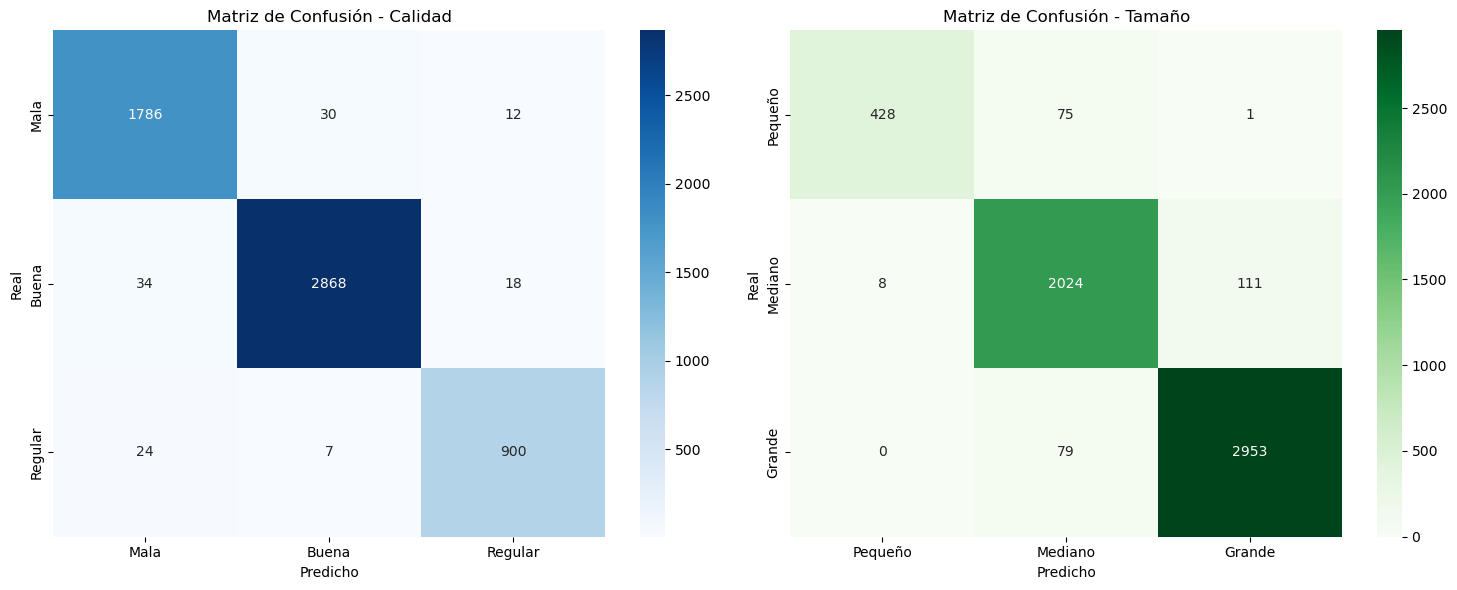

In [12]:
# y_test[:, 0] es calidad, y_test[:, 1] es tamaño
evaluate_multioutput_model(
    y_test[:, 0], y_pred_rf[:, 0],
    y_test[:, 1], y_pred_rf[:, 1],
    quality_classes=quality_names,
    size_classes=size_names
)


In [13]:
print(f"X_train shape: {X_train.shape}")
print(f"Número de features: {X_train.shape[1]}")
print(f"Número de muestras: {X_train.shape[0]}")

X_train shape: (22716, 513)
Número de features: 513
Número de muestras: 22716


### 4. Ajuste de Hiperparámetros (Hyperparameter Tuning)

Aplicamos `RandomizedSearchCV` para buscar una buena combinación de parámetros sin probar todas las combinaciones posibles.

**Nota:** al usar `MultiOutputClassifier` y `Pipeline`, debemos acceder a los parámetros del modelo base especificando la ruta completa en el diccionario de parámetros: `classifier__estimator__<parametro>`. El `class_weight='balanced'` se mantiene dentro del estimador base para corregir el desbalance de clases.

In [14]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

# RandomizedSearch prueba combinaciones aleatorias sin perder el class_weight='balanced'
# definido dentro de rf_base.
param_dist = {
    'classifier__estimator__n_estimators': randint(50, 200),
    'classifier__estimator__max_depth': [None, 10, 20, 30],
    'classifier__estimator__min_samples_split': [2, 5, 10],
    'classifier__estimator__min_samples_leaf': [1, 2, 4]
}

grid_search = RandomizedSearchCV(
    pipeline_rf,
    param_distributions=param_dist,
    n_iter=10,
    cv=3,
    n_jobs=4,
    verbose=2,
    random_state=42
)

grid_search.fit(X_train, y_train)

print(f'Mejores parámetros encontrados: {grid_search.best_params_}')
best_rf_model = grid_search.best_estimator_


Fitting 3 folds for each of 10 candidates, totalling 30 fits
Mejores parámetros encontrados: {'classifier__estimator__max_depth': 30, 'classifier__estimator__min_samples_leaf': 1, 'classifier__estimator__min_samples_split': 2, 'classifier__estimator__n_estimators': 152}


### 5. Evaluación del Mejor Modelo Encontrado

REPORTE DE CLASIFICACIÓN: CALIDAD
              precision    recall  f1-score   support

        Mala       0.97      0.98      0.97      1828
       Buena       0.99      0.98      0.98      2920
     Regular       0.96      0.97      0.96       931

    accuracy                           0.98      5679
   macro avg       0.97      0.98      0.97      5679
weighted avg       0.98      0.98      0.98      5679

REPORTE DE CLASIFICACIÓN: TAMAÑO
              precision    recall  f1-score   support

     Pequeño       0.98      0.86      0.91       504
     Mediano       0.93      0.94      0.94      2143
      Grande       0.96      0.97      0.97      3032

    accuracy                           0.95      5679
   macro avg       0.96      0.92      0.94      5679
weighted avg       0.95      0.95      0.95      5679



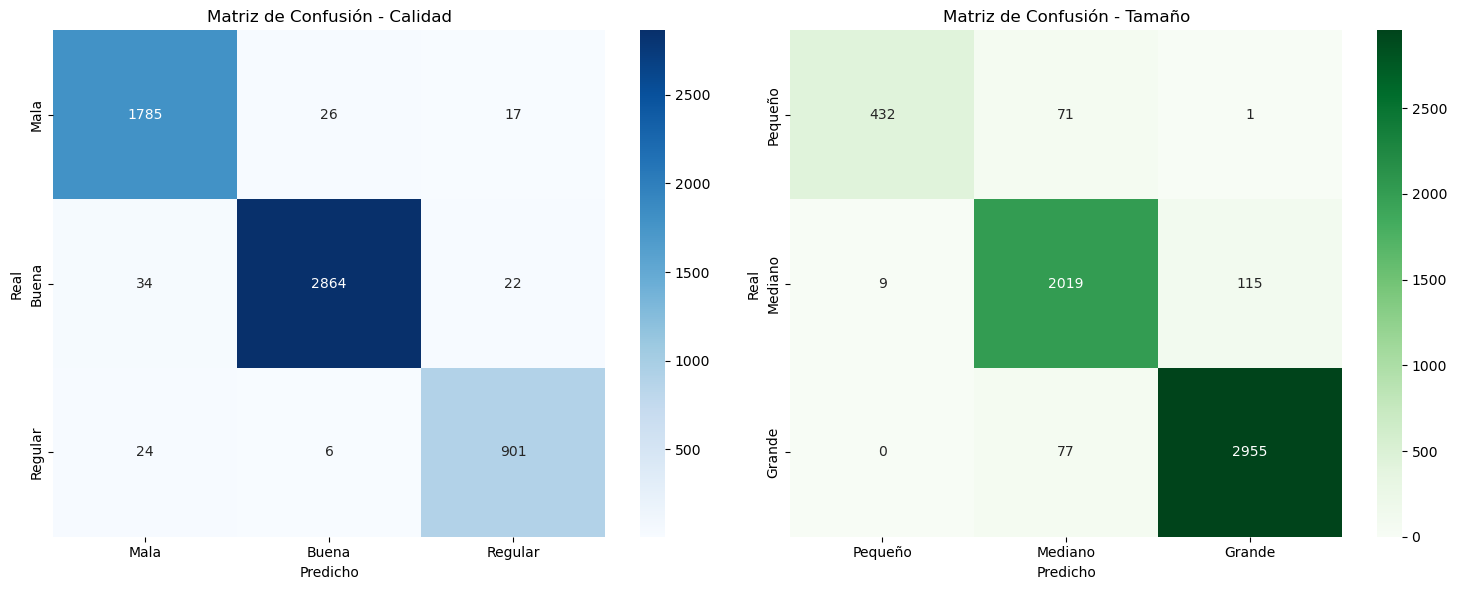

In [15]:
y_pred_best = best_rf_model.predict(X_test)

evaluate_multioutput_model(
    y_test[:, 0], y_pred_best[:, 0],
    y_test[:, 1], y_pred_best[:, 1],
    quality_classes=quality_names,
    size_classes=size_names
)


### 6. Guardar el Modelo Entrenado

Guardamos el mejor modelo utilizando `joblib` para poder consumirlo posteriormente en la interfaz de Streamlit (`app.py`).

In [16]:
# Guardar en la carpeta definida por la estructura del proyecto
model_dir = '../saved_models'
os.makedirs(model_dir, exist_ok=True)

model_path = os.path.join(model_dir, 'best_rf_multioutput.pkl')
joblib.dump(best_rf_model, model_path)

print(f'Modelo guardado exitosamente en: {model_path}')


Modelo guardado exitosamente en: ../saved_models/best_rf_multioutput.pkl
